In [2]:
# Import our tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df=sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
df.shape

(891, 15)

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
# Fix age - fill with median
df['age'].fillna(df['age'].median(), inplace=True)

# Fix embarked - only 2 missing, fill with most common value
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Fix deck - too many missing (688!), just drop the whole column
df.drop(columns=['deck'], inplace=True)

# Confirm no more missing values
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_11132\2266259252.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\acer\AppData\Local\Temp\ipykernel_11132\2266259252.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [9]:
# Modern pandas style - no inplace
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Confirm all zeros
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [10]:
# Drop useless columns
df = df.drop(columns=['alive', 'who', 'embark_town', 'class', 'adult_male'])

# Check what we have left
print(df.columns)
print(df.shape)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'alone'],
      dtype='object')
(891, 9)


In [11]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,True
887,1,1,female,19.0,0,0,30.0000,S,True
888,0,3,female,28.0,1,2,23.4500,S,False
889,1,1,male,26.0,0,0,30.0000,C,True


In [12]:
# Encode sex
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Encode embarked
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Encode alone
df['alone'] = df['alone'].map({True: 1, False: 0})

# Check
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,0,22.0,1,0,7.2500,0,0
1,1,1,1,38.0,1,0,71.2833,1,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,0
4,0,3,0,35.0,0,0,8.0500,0,1


In [13]:
# X = everything except survived (our features)
# y = survived (what we want to predict)

X = df.drop(columns=['survived'])
y = df['survived']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 8)
y shape: (891,)


In [14]:
# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (712, 8)
Testing size: (179, 8)


In [15]:
# Create and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 79.89%

Confusion Matrix:
[[90 15]
 [21 53]]


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [18]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
# n_estimators = number of trees in the forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
model_rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [19]:
# Make predictions
y_pred_rf = model_rf.predict(X_test)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")
print(f"Logistic Regression Accuracy: 79.89%")
print(f"\nImprovement: {(accuracy_rf * 100) - 79.89:.2f}%")

# Full report
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 83.24%
Logistic Regression Accuracy: 79.89%

Improvement: 3.35%
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [20]:
# Feature importance
importances = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances)

fare        0.283010
sex         0.257595
age         0.251941
pclass      0.080330
sibsp       0.043515
embarked    0.034419
parch       0.033629
alone       0.015561
dtype: float64


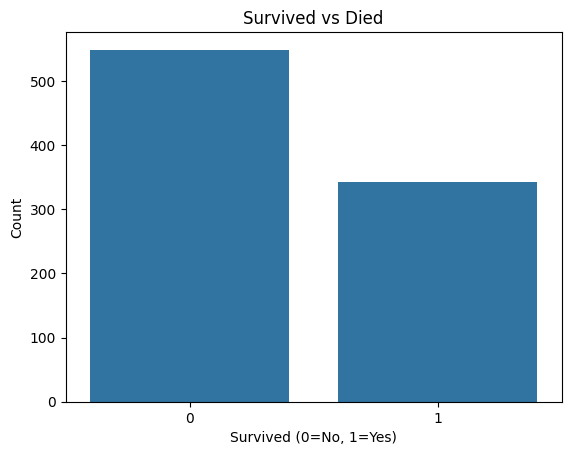

In [21]:
# Count of survivors vs non survivors
sns.countplot(x='survived', data=df)
plt.title('Survived vs Died')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

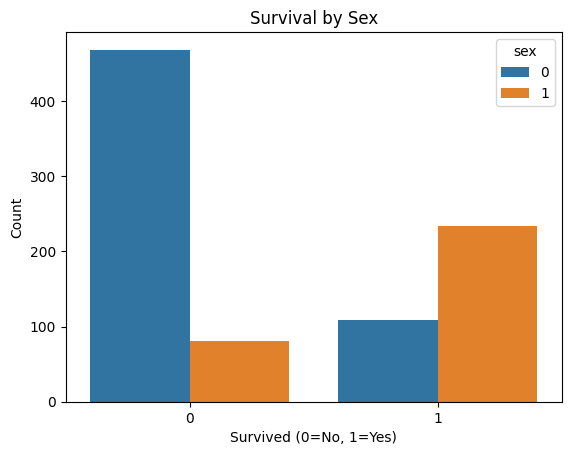

In [22]:
# Survival by sex
sns.countplot(x='survived', hue='sex', data=df)
plt.title('Survival by Sex')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

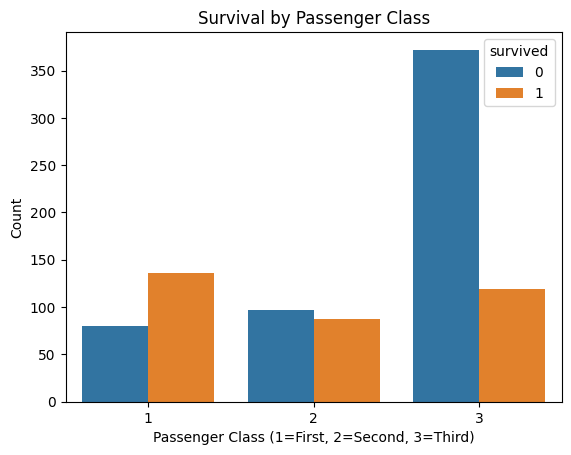

In [23]:
# Survival by passenger class
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.show()

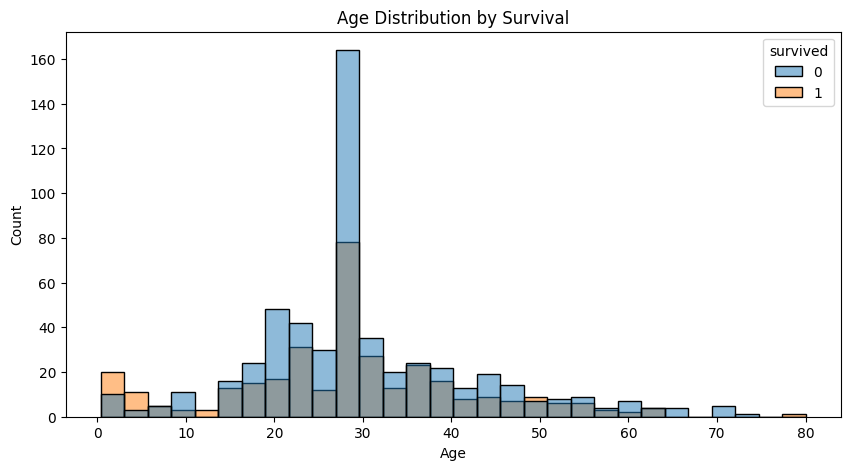

In [24]:
# Age distribution of survivors vs non survivors
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', hue='survived', bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

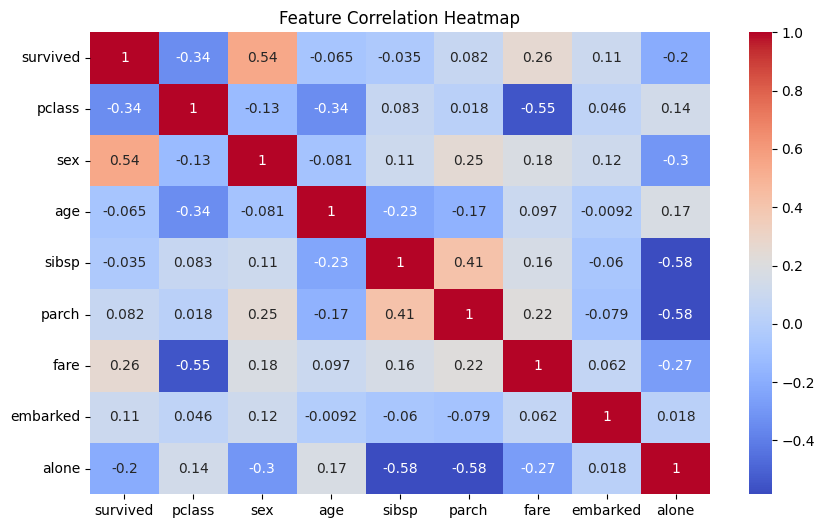

In [25]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()